### Simulacion de Procesos Financieros
**Andre Esteban Vera - 745232**
19/08/2026

## Clase 3 - Black - Scholes

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

S0    = 100      # precio inicial
K     = 110      # strike
r     = 0.05     # tasa libre de riesgo
sigma = 0.20     # volatilidad
T     = 1        # horizonte en años
M     = 10_000   # número de simulaciones

In [26]:
np.random.normal?

Signature: np.random.normal(loc=0.0, scale=1.0, size=None)
Docstring:
normal(loc=0.0, scale=1.0, size=None)

Draw random samples from a normal (Gaussian) distribution.

The probability density function of the normal distribution, first
derived by De Moivre and 200 years later by both Gauss and Laplace
independently [2]_, is often called the bell curve because of
its characteristic shape (see the example below).

The normal distributions occurs often in nature.  For example, it
describes the commonly occurring distribution of samples influenced
by a large number of tiny, random disturbances, each with its own
unique distribution [2]_.

.. note::
    New code should use the `~numpy.random.Generator.normal`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

Parameters
----------
loc : float or array_like of floats
    Mean ("centre") of the distribution.
scale : float or array_like of floats
    Standard deviation (spread or "width")

In [27]:
Z = np.random.normal(0, 1, M)

ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

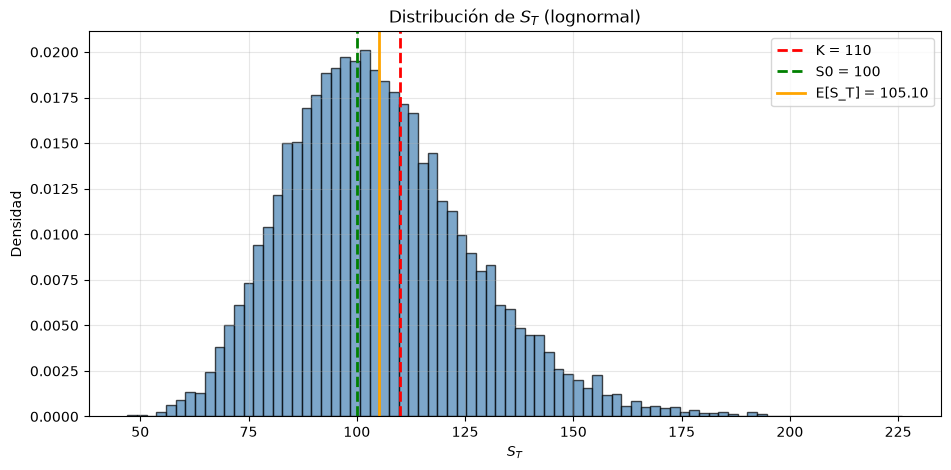

In [28]:
# Histograma de la distribución de S_T

plt.figure(figsize=(11,5))
plt.hist(ST, bins=80, density=True, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(K, color='red', linestyle='--', linewidth=2, label=f'K = {K}')
plt.axvline(S0, color='green', linestyle='--', linewidth=2, label=f'S0 = {S0}')
plt.axvline(ST.mean(), color='orange', linestyle='-', linewidth=2, label=f'E[S_T] = {ST.mean():.2f}')
plt.title('Distribución de $S_T$ (lognormal)')
plt.xlabel('$S_T$')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [29]:
# sin formula
import numpy as np
import matplotlib.pyplot as plt

s_0, k, r, desv, T, m = 100, 110, 0.05, 0.20, 1, 10000

np.random.seed(42)

resultados = []
for i in range(m):
    z = np.random.normal(0, 1)
    s_t = s_0*np.exp((r - 0.5*desv**2)*T + desv*np.sqrt(T)*z)
    if s_t > k:
        resultados.append(s_t - k)
    else:
        resultados.append(0)

precio = np.exp(-r*T) * np.mean(resultados)
print(f"Precio : {precio:.4f}")

Precio : 6.0447


In [30]:
# Black-Scholes con formula
def bs_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

precio_bs = bs_call(S0, K, r, sigma, T)

print(f"Black-Scholes  : {precio_bs:.4f}")

Black-Scholes  : 6.0401


In [31]:
# ahora MonteCarlo
payoff = np.maximum(ST - K, 0)
precio_mc = np.exp(-r*T) * payoff.mean()
se = np.exp(-r*T) * payoff.std(ddof=1) / np.sqrt(M)

print(f"Precio Monte Carlo : {precio_mc:.4f}")
print(f"Error estándar     : {se:.4f}")
print(f"IC 95%             : [{precio_mc - 1.96*se:.4f}, {precio_mc + 1.96*se:.4f}]")
print(f"P(ejercer)         : {(ST > K).mean():.4f}")
print(f"Diferencia BS - MC : {abs(precio_bs - precio_mc):.4f}")

Precio Monte Carlo : 6.0447
Error estándar     : 0.1171
IC 95%             : [5.8152, 6.2742]
P(ejercer)         : 0.3708
Diferencia BS - MC : 0.0046


In [32]:
import pandas as pd

detalle = pd.DataFrame({
    'S_T': ST,
    'Ejerce': ST > K,
    'Payoff': np.maximum(ST - K, 0)
})

print(detalle.head(15).round(4).to_string(index=False))
print(f"\nSimulaciones que ejercen : {(ST > K).sum():,} de {M:,}")
print(f"Probabilidad de ejercer  : {(ST > K).mean():.4f}")
print(f"Payoff promedio total    : {detalle['Payoff'].mean():.4f}")
print(f"Payoff promedio | ejerce : {detalle.loc[detalle['Ejerce'], 'Payoff'].mean():.4f}")

     S_T  Ejerce  Payoff
113.8080    True  3.8080
100.2350   False  0.0000
117.2968    True  7.2968
139.7390    True 29.7390
 98.3310   False  0.0000
 98.3313   False  0.0000
141.3180    True 31.3180
120.1399    True 10.1399
 93.8104   False  0.0000
114.8563    True  4.8563
 93.9241   False  0.0000
 93.8806   False  0.0000
108.1547   False  0.0000
 70.2819   False  0.0000
 72.9801   False  0.0000

Simulaciones que ejercen : 3,708 de 10,000
Probabilidad de ejercer  : 0.3708
Payoff promedio total    : 6.3546
Payoff promedio | ejerce : 17.1377


In [33]:
# Precio Justo de la opcion
print(f"Precio Black-Scholes : {precio_bs:.4f}")
print(f"Precio Monte Carlo   : {precio_mc:.4f}")

Precio Black-Scholes : 6.0401
Precio Monte Carlo   : 6.0447


In [34]:
# Caso 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(32)

S0    = 40
mu    = 0.16
sigma = 0.20
T     = 0.5          
M     = 10_000

# ln(S_T) ~ N(media_log, var_log)
media_log = np.log(S0) + (mu - 0.5*sigma**2)*T
var_log   = sigma**2 * T
sd_log    = np.sqrt(var_log)

print(f"ln(S_T) ~ N({media_log:.4f}, {var_log:.4f})")
print(f"Desviación estándar del log: {sd_log:.4f}")

ln(S_T) ~ N(3.7589, 0.0200)
Desviación estándar del log: 0.1414


In [35]:
# Intervalo de confianza del 95%
z = 1.96

lim_inf_log = media_log - z*sd_log
lim_sup_log = media_log + z*sd_log

lim_inf = np.exp(lim_inf_log)
lim_sup = np.exp(lim_sup_log)

print(f"IC 95% para ln(S_T): [{lim_inf_log:.4f}, {lim_sup_log:.4f}]")
print(f"IC 95% para S_T   : [{lim_inf:.4f}, {lim_sup:.4f}]")

IC 95% para ln(S_T): [3.4817, 4.0361]
IC 95% para S_T   : [32.5147, 56.6032]
